In [12]:
import json
import os

import duckdb
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
import numpy as np
import pandas as pd
from pathlib import Path

In [13]:
PALETTE = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B2", "#937860"]
DATABASE_PATH = "../../database/eBuS.duckdb"
OUTPUT_PATH = Path(r"C:\Users\svens\Nextcloud\Masterarbeit\Grafiken\NewPlots")

summer


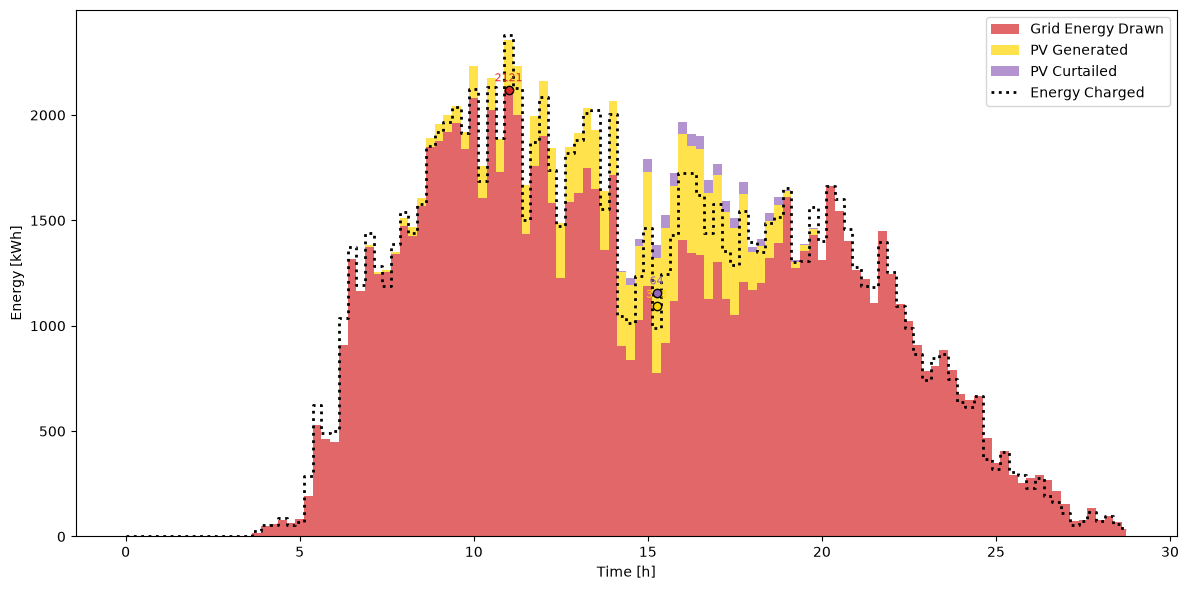

winter


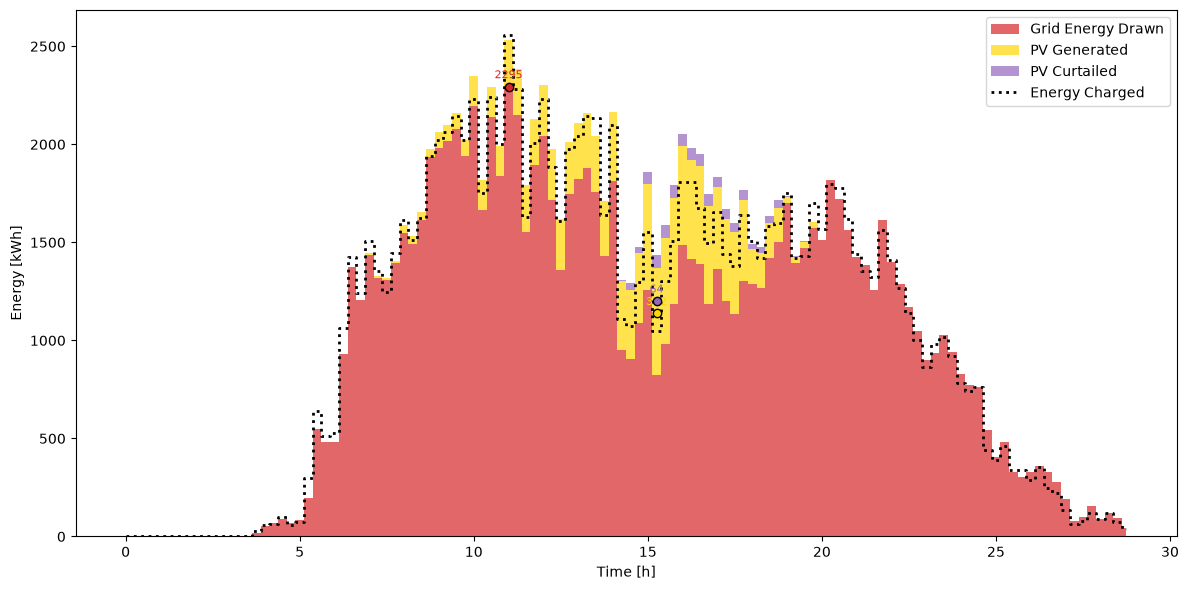

reduced


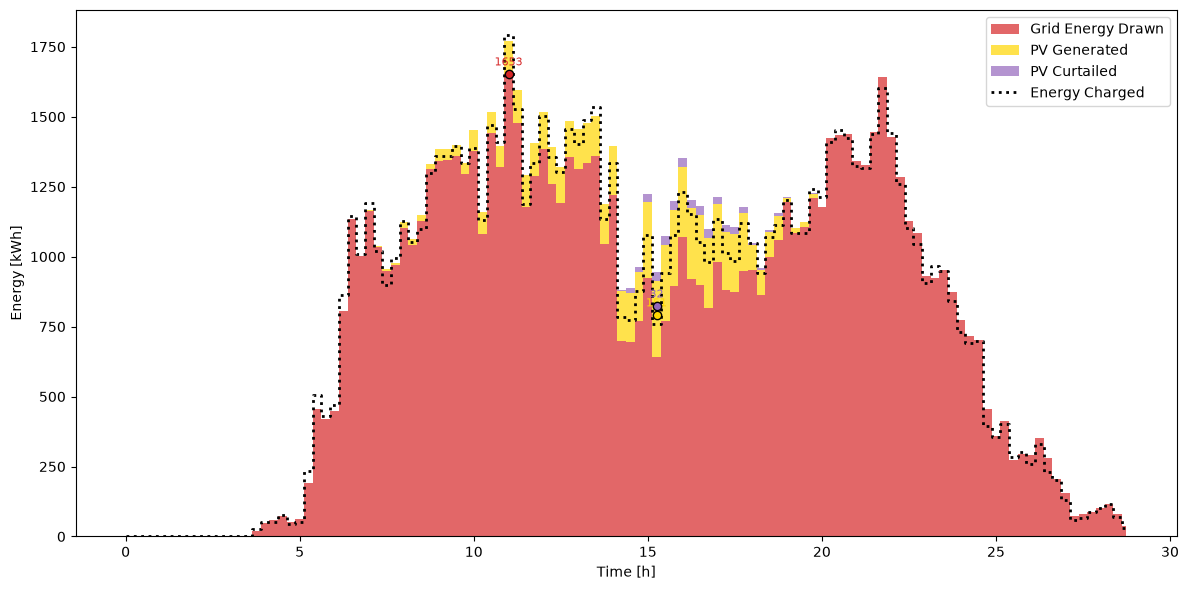

increased


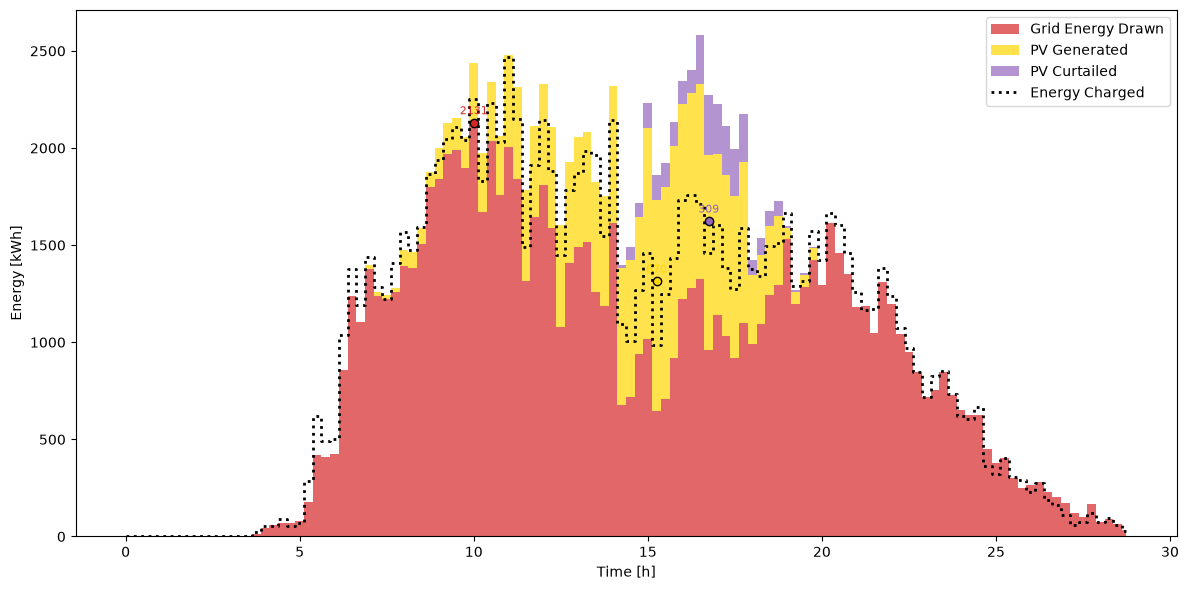

In [34]:
def stacked_ieh_power_no_depot(output_dir=OUTPUT_PATH):

    con = duckdb.connect(DATABASE_PATH)

    df = con.execute(
        """
        SELECT
            timestep_time,
            station_gridEnergyDrawn,
            station_pvCurtailed,
            station_pvGenerated,
            station_energyChargedBus,
            station_energyChargedStorage,
            scenario
        FROM multirun_ess
        WHERE seed = 65
        AND station_id NOT LIKE 'cd_%'
        ORDER BY timestep_time
        """
    ).fetchdf()

    station_df =  con.execute(
        """
        SELECT
            timestep_time,
            station_gridEnergyDrawn,
            station_pvCurtailed,
            station_pvGenerated,
            station_energyChargedBus,
            station_energyChargedStorage,
            scenario
        FROM multirun_ess
        WHERE seed = 65
        AND station_id NOT LIKE 'cd_%'
        ORDER BY timestep_time
        """
    ).fetchdf()

    con.close()

    for scenario in ["summer", "winter", "reduced", "increased"]:

        subset = df[df["scenario"] == scenario].copy()

        energy_cols = [
            "station_gridEnergyDrawn",
            "station_pvCurtailed",
            "station_pvGenerated",
            "station_energyChargedBus",
            "station_energyChargedStorage",
        ]

        # Aggregate every 900 seconds = 15 minutes
        subset["time_5min"] = (subset["timestep_time"] // 900) * 900

        totals = subset.groupby("time_5min")[energy_cols].sum().reset_index()

        # Convert energy from Wh to kWh
        totals[energy_cols] = totals[energy_cols] / 1000

        # Convert seconds to hours for the x-axis
        totals["timestep_time"] = totals["time_5min"] / 3600
        
        fig, ax = plt.subplots(figsize=(12, 6))


        ax.stackplot(
            totals["timestep_time"],
            totals["station_gridEnergyDrawn"],
            totals["station_pvGenerated"],
            totals["station_pvCurtailed"],
            alpha=0.7,
            step="mid",
            labels=[
                "Grid Energy Drawn",
                "PV Generated",
                "PV Curtailed",
            ],
            colors=["tab:red", "gold", "tab:purple"],
        )
  
        ax.step(
            totals["timestep_time"],
            totals["station_energyChargedBus"],
            color="black",
            where="mid",
            linewidth=2,
            linestyle=":",
            label="Energy Charged",
        )


        series = [
            ("Grid Energy Drawn", totals["station_gridEnergyDrawn"], "tab:red"),
            ("PV Generated", totals["station_energyChargedStorage"], "gold"),
            ("PV Curtailed", totals["station_pvCurtailed"], "tab:purple"),
        ]

        cumulative = np.zeros(len(totals))
        for label, values, color in series:
            cumulative += values.to_numpy()
            peak_idx = values.idxmax()
            peak_x = totals["timestep_time"].loc[peak_idx]
            peak_y = cumulative[peak_idx]
            peak_val = values.loc[peak_idx]

            ax.scatter(peak_x, peak_y, color=color, edgecolor="black", zorder=5)
            ax.annotate(
                f"{peak_val:.0f}",
                (peak_x, peak_y),
                textcoords="offset points", xytext=(0, 6),
                fontsize=8, color=color, ha="center",
            )

        ax.set_xlabel("Time [h]")
        ax.set_ylabel("Energy [kWh]")
        ax.legend()

        fig.savefig(
            os.path.join(output_dir, f"{scenario}_ess_stacked_depot.pdf")
        )
        plt.tight_layout()
        print(scenario)
        plt.show()

stacked_ieh_power_no_depot()

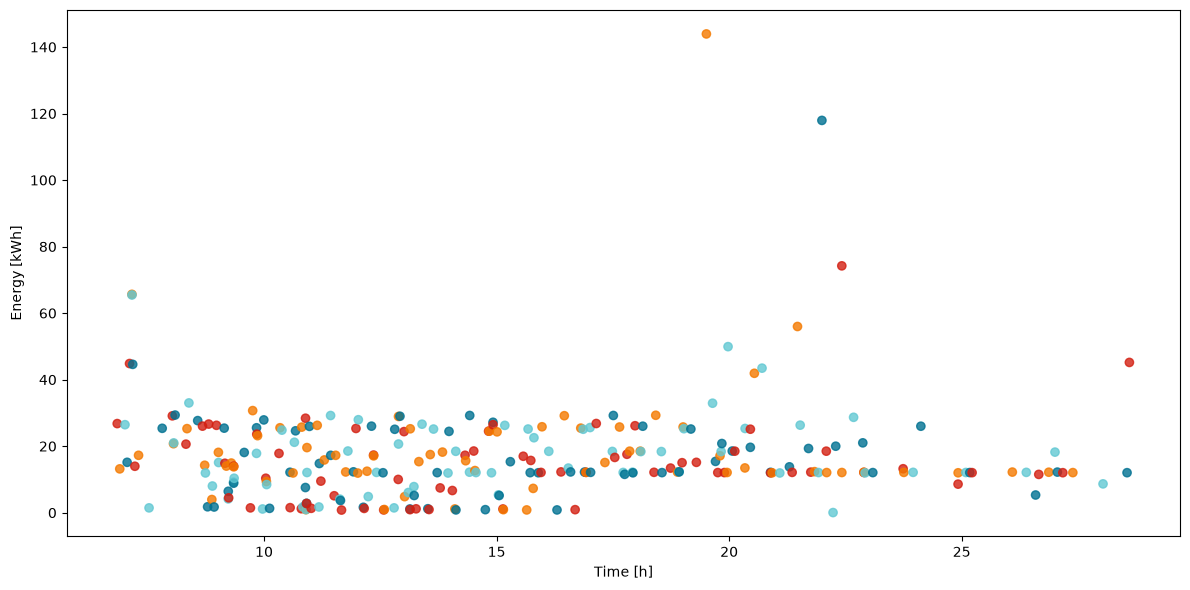

In [50]:
def single_station_events(station_id):
    con = duckdb.connect(DATABASE_PATH)

    df = con.execute(
        """
        SELECT chargingEvent_chargingBegin,
               scenario,
               seed,
               chargingEvent_chargingStationId,
               chargingEvent_totalEnergyChargedIntoVehicle
        FROM multirun_chargingstations
        WHERE scenario = 'summer'
          AND seed = 65
          AND chargingEvent_chargingStationId = ?
          AND chargingEvent_totalEnergyChargedIntoVehicle > 0
        ORDER BY chargingEvent_chargingBegin
        """,
        [station_id]
    ).fetchdf()

    con.close()

    fig, ax = plt.subplots(figsize=(12, 6))

    colors = ["#d31f11", "#f47a00", "#62c8d3", "#007191"]

    ax.scatter(
        df["chargingEvent_chargingBegin"] / 3600,
        df["chargingEvent_totalEnergyChargedIntoVehicle"] / 1000,
        alpha=0.8,
        color=[colors[i % len(colors)] for i in range(len(df))]
    )

    ax.set_xlabel("Time [h]")
    ax.set_ylabel("Energy [kWh]")

    fig.tight_layout()

    fig.savefig(
        os.path.join(OUTPUT_PATH, f"{station_id}_station_events.pdf")
    )

    plt.show()

single_station_events("cs_agg_12763_36_12771_0")

In [5]:
def single_station_stacked(station_id):
    con = duckdb.connect(DATABASE_PATH)

    df = con.execute(
        """
        SELECT
            timestep_time,
            station_gridEnergyDrawn,
            station_pvCurtailed,
            station_pvGenerated,
            station_energyCharged,
            scenario,
            seed
        FROM multirun_ess
        WHERE scenario = 'summer'
          AND seed = 65
          AND station_id = ?
        ORDER BY timestep_time
        """,
        [station_id]
    ).fetchdf()
    con.close()

    df["station_gridEnergyDrawn"] = df["station_gridEnergyDrawn"] /1000
    df["station_pvGenerated"] = df["station_pvGenerated"] / 1000 
    df["station_pvCurtailed"] = df["station_pvCurtailed"] / 1000
    df["station_energyCharged"] = df["station_energyCharged"] / 1000
    df["timestep_time"] = df["timestep_time"] / 3600

    pv_stored_or_charged = df["station_pvGenerated"] - df["station_pvCurtailed"]


    fig, ax = plt.subplots(figsize=(12, 6))

    ax.stackplot(
        df["timestep_time"],
        df["station_gridEnergyDrawn"],
        pv_stored_or_charged,
        df["station_pvCurtailed"],
        alpha=0.7,
        step="mid",
        labels=[
            "Grid Energy Drawn",
            "PV Generated",
            "PV Curtailed",
        ],
        colors=["tab:red", "gold", "tab:purple"],
    )

    ax.set_xlabel("Time [h]")
    ax.set_ylabel("Energy [kWh]")
    ax.legend()
    ax.grid(True)

    fig.tight_layout()

    fig.savefig(
        os.path.join(OUTPUT_PATH, f"{station_id}_station_stacked.pdf")
    )

    plt.show()

single_station_stacked("cs_agg_10671_36_11882_47_11989_25")

BinderException: Binder Error: Referenced column "station_energyCharged" not found in FROM clause!
Candidate bindings: "station_energyChargedBus", "station_energyChargedStorage", "station_pvGenerated", "station_gridEnergyDrawn", "station_pvCurtailed"

LINE 7:             station_energyCharged,
                    ^

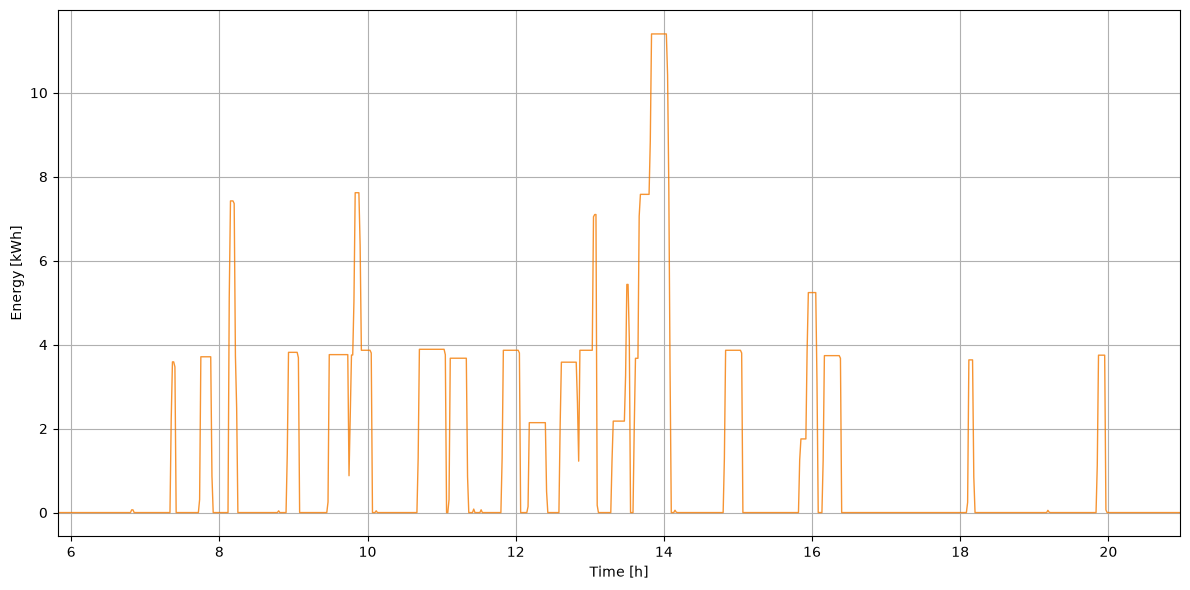

In [92]:
def single_station_charged(station_id):
    con = duckdb.connect(DATABASE_PATH)

    df = con.execute(
        """
        SELECT
            timestep_time,
            station_energyCharged,
            scenario,
            seed
        FROM multirun_ess
        WHERE scenario = 'summer'
          AND seed = 65
          AND station_id = ?
        ORDER BY timestep_time
        """,
        [station_id]
    ).fetchdf()
    con.close()

    df["timestep_time"] = df["timestep_time"] / 3600
    df["station_energyCharged"] = df["station_energyCharged"] / 1000

    fig, ax = plt.subplots(figsize=(12, 6))

    ax.plot(
        df["timestep_time"],
        df["station_energyCharged"],
        color="#f47a00",
        linewidth=1,
        alpha=0.8,
        label="Energy Charged",
    )

    # Find the period where anything is happening
    activity = (df["station_energyCharged"].abs())

    active = activity > 0

    if active.any():
        first_active = df.loc[active, "timestep_time"].iloc[0]
        last_active = df.loc[active, "timestep_time"].iloc[-1]

        ax.set_xlim(
            first_active - 1,
            last_active + 1
        )

    ax.set_xlabel("Time [h]")
    ax.set_ylabel("Energy [kWh]")
    ax.grid(True)

    fig.tight_layout()

    fig.savefig(
        os.path.join(OUTPUT_PATH, f"{station_id}_station_charged.pdf")
    )

    plt.show()

single_station_charged("cs_agg_10671_36_11882_47_11989_25")

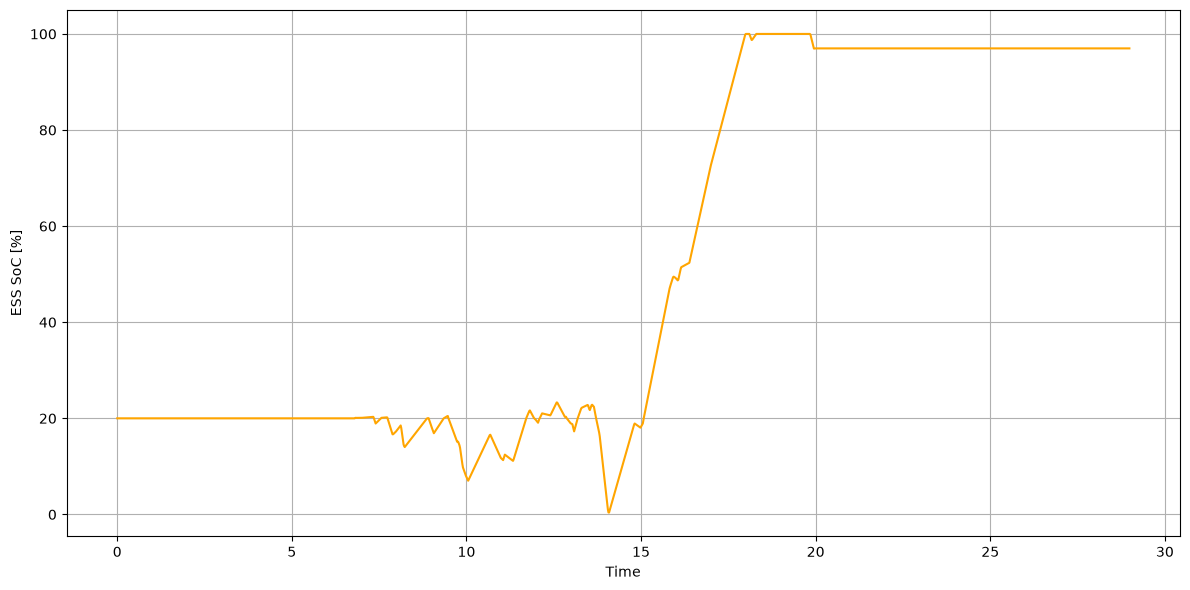

In [80]:
def ess_soc_over_time(station_id):

    con = duckdb.connect(DATABASE_PATH)

    df = con.execute(
        """
        SELECT
            timestep_time,
            station_essSoc,
            station_id,
            station_capacity,
            scenario,
            seed
        FROM multirun_ess
        WHERE seed = 65
        AND scenario = 'summer'
        AND station_id = ?
        ORDER BY timestep_time
        """,
        [station_id]
    ).fetchdf()

    con.close()

    df["timestep_time"] = df["timestep_time"] / 3600
    df["station_essSoc_pct"] = df["station_essSoc"] / df["station_capacity"] * 100

    fig, ax = plt.subplots(figsize=(12, 6))

    ax.plot(
        df["timestep_time"],
        df["station_essSoc_pct"],
        color="orange",
        label=station_id
    )

    ax.set_xlabel("Time")
    ax.set_ylabel("ESS SoC [%]")
    ax.grid(True)

    plt.tight_layout()

    fig.savefig(
        os.path.join(
            OUTPUT_PATH,
            f"{station_id}_ess_over_time.pdf"
        )
    )

    plt.show()
    plt.close(fig)
ess_soc_over_time("cs_agg_10671_36_11882_47_11989_25")
